In [26]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import ast
from pandas import json_normalize
from tqdm import tqdm
import folium
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

In [8]:
coffee_df = pd.read_csv("C:/Users/10919/PTUA2025/Starbucks_Location_worldwide/directory.csv")

In [10]:
print(coffee_df.columns)

Index(['Brand', 'Store Number', 'Store Name', 'Ownership Type',
       'Street Address', 'City', 'State/Province', 'Country', 'Postcode',
       'Phone Number', 'Timezone', 'Longitude', 'Latitude'],
      dtype='object')


In [12]:
coffee_df.rename(columns={
    'Brand': 'brand',
    'Store Number': 'store_number',
    'Store Name': 'store_name',
    'Ownership Type': 'ownership_type',
    'Street Address': 'address',
    'City': 'city',
    'State/Province': 'state_province',
    'Country': 'country',
    'Postcode': 'postcode',
    'Phone Number': 'phone_number',
    'Timezone': 'timezone',
    'Longitude': 'longitude',
    'Latitude': 'latitude'
}, inplace=True)

In [14]:
north_bound = 60.8590
south_bound = 54.6356
west_bound = -7.385
east_bound = 1.7834

In [18]:
filtered_df = coffee_df[(coffee_df['latitude'] <= north_bound) & (coffee_df['latitude'] >= south_bound) &
                 (coffee_df['longitude'] >= west_bound) & (coffee_df['longitude'] <= east_bound)]

In [22]:
geometry = [Point(xy) for xy in zip(filtered_df['longitude'], filtered_df['latitude'])]
gdf = gpd.GeoDataFrame(filtered_df, geometry=geometry)
gdf.set_crs(epsg=4326, inplace=True)

,brand,store_number,store_name,ownership_type,address,city,state_province,country,postcode,phone_number,timezone,longitude,latitude,geometry
5395,Starbucks,20724-208164,Cineworld Boldon,Licensed,"Cineworld Cinemas, Boldon Colliery, Leisure Pa...",Boldon,ENG,GB,NE35 9PB,0191 536 0913,GMT+0:00 Europe/London,-1.47,54.95,POINT (-1.47 54.95)
5451,Starbucks,12899-137735,Carlisle - Scotch Street,Company Owned,"CARLISLE - SCOTCH STREET(64), 64,SCOTCH STREET",Carlisle,ENG,GB,CA3 8PN,1228535549,GMT+0:00 Europe/London,-2.94,54.90,POINT (-2.94 54.9)
5476,Starbucks,24179-227649,"Cockermouth, Oakhurst Services",Franchise,"Pakhurst Service Station, Lamplugh Road",Cockermouth,ENG,GB,CA13 0QT,01900 827419,GMT+0:00 Europe/London,-3.37,54.65,POINT (-3.37 54.65)
5501,Starbucks,17503-182544,Marriott Hotel Durham,Licensed,"Old Elvet, North East Outlet Centre",Durham,ENG,GB,DH1 3JN,1913753614,GMT+0:00 Europe/London,-1.57,54.78,POINT (-1.57 54.78)
5502,Starbucks,12390-83728,Dalton Park Outlet Centre,Company Owned,"North East Outlet Centre, Dalton Park, 2/3 Bri...",Durham,ENG,GB,SR7 9HU,1915269993,GMT+0:00 Europe/London,-1.37,54.82,POINT (-1.37 54.82)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6207,Starbucks,18425-190949,SSP Glasgow Airside,Licensed,Ground Floor Arrivals,Paisley,SCT,GB,PA3 2SW,0141 848 4746,GMT+0:00 Europe/London,-4.43,55.86,POINT (-4.43 55.86)
6208,Starbucks,22106-217704,Perth - High Street,Franchise,189 High Street,Perth,SCT,GB,PH1 5UN,NaN,GMT+0:00 Europe/London,-3.43,56.40,POINT (-3.43 56.4)
6209,Starbucks,31126-106654,SSP Prestwick Airport,Licensed,Terminal Building,Prestwick,SCT,GB,KA9 2PL,NaN,GMT+0:00 Europe/London,-4.61,55.51,POINT (-4.61 55.51)
6210,Starbucks,12594-98117,St Andrews - Market Street,Company Owned,127/129 Market Street,St Andrews,SCT,GB,KY16 9PE,1334470938,GMT+0:00 Europe/London,-2.80,56.34,POINT (-2.8 56.34)


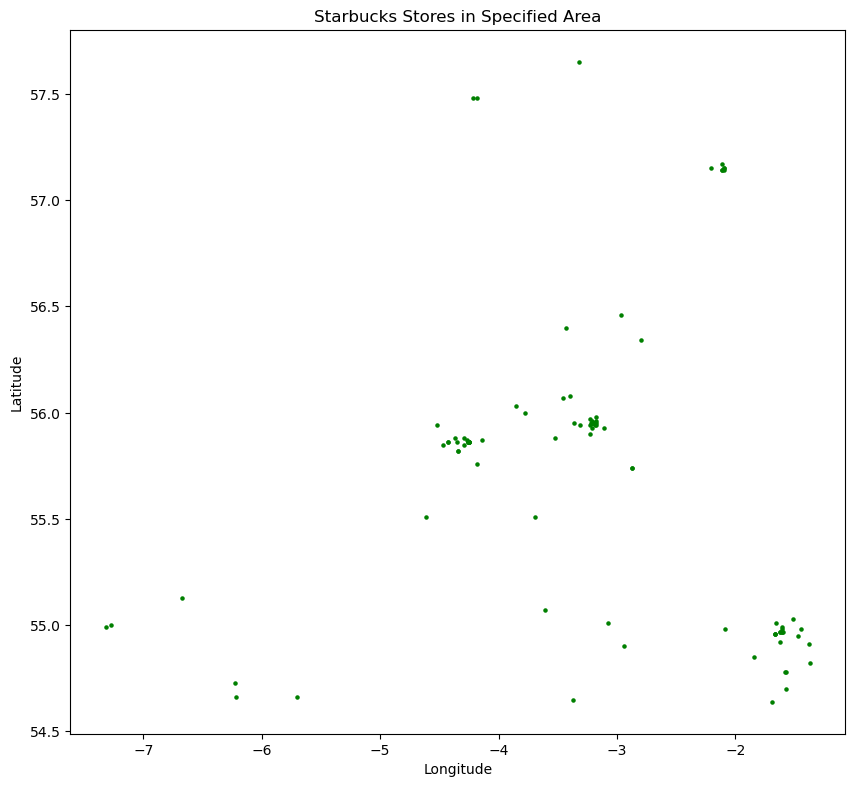

In [28]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, marker='o', color='green', markersize=5)
ax.set_title('Starbucks Stores in Specified Area')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [36]:
coffee_df.dropna(subset=['latitude', 'longitude'], inplace=True)
map_center = [coffee_df['latitude'].mean(), coffee_df['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=7)

# 添加门店标记
for idx, row in coffee_df.iterrows():
    folium.Marker(
        [row['latitude'], row['longitude']],
        popup=f"{row['store_name']}<br>{row['address']}<br>{row['ownership_type']}"
    ).add_to(m)

# 保存地图为 HTML 文件
m.save("starbucks_scotland_map.html")

print("Interactive map saved as 'starbucks_scotland_map.html'")

Interactive map saved as 'starbucks_scotland_map.html'
